In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
dftrain = pd.read_csv('housing.csv')

In [134]:
dftrain

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [135]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [136]:
for col in dftrain.columns:
    if dftrain[col].dtype == 'object':
        dftrain[col] = dftrain[col].fillna(dftrain[col].mode()[0])
    else:
        dftrain[col] = dftrain[col].fillna(dftrain[col].mean())


dftrain = pd.get_dummies(dftrain, drop_first=True)

for cols in dftrain.select_dtypes(include='bool').columns:
    dftrain[cols] = dftrain[cols].astype(int)

In [137]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  int64  
 10  ocean_proximity_ISLAND      20640 non-null  int64  
 11  ocean_proximity_NEAR BAY    20640 non-null  int64  
 12  ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory 

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
dftrain.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>],
       [<Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'ocean_proximity_INLAND'}>,
        <Axes: title={'center': 'ocean_proximity_ISLAND'}>,
        <Axes: title={'center': 'ocean_proximity_NEAR BAY'}>],
       [<Axes: title={'center': 'ocean_proximity_NEAR OCEAN'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

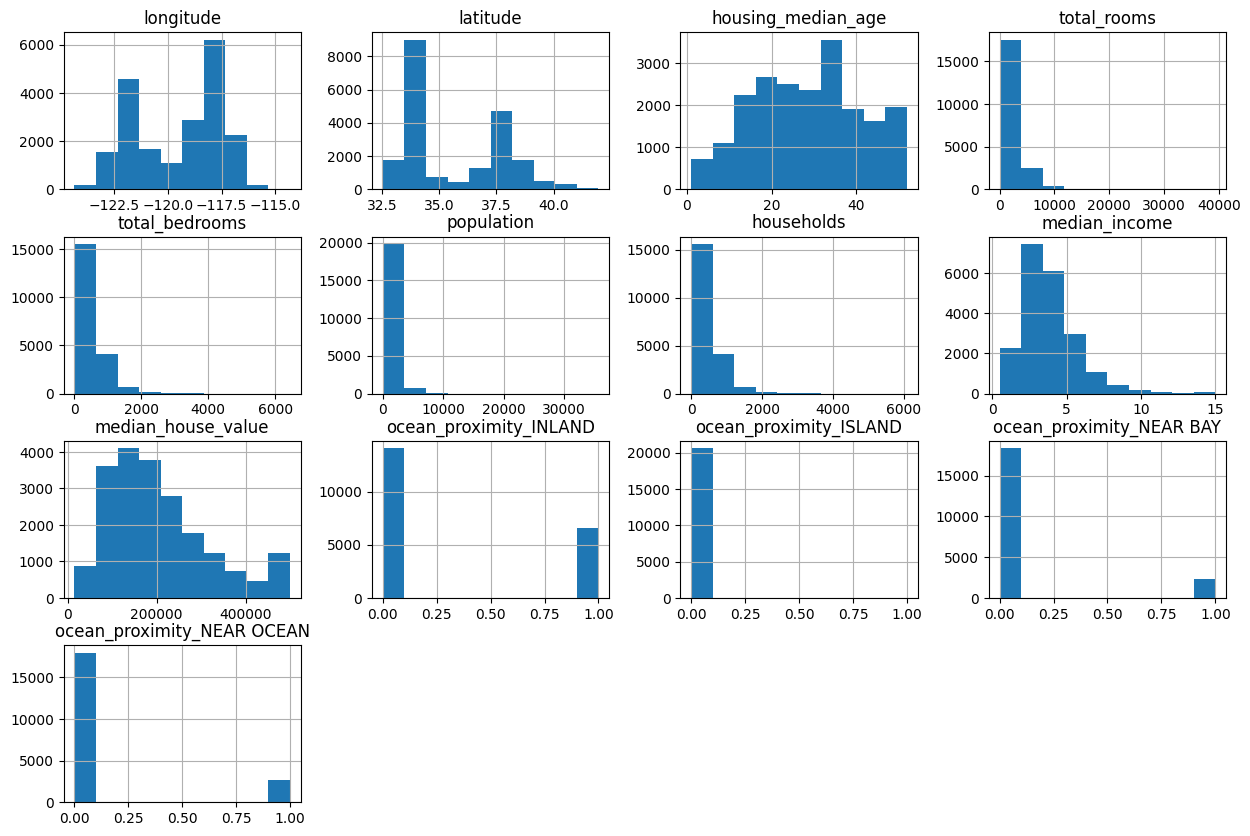

In [140]:
dftrain.hist(figsize=(15,10))

In [141]:
cols_tolog = [ 'total_rooms',
       'total_bedrooms', 'population', 'households']
for c in cols_tolog:
    dftrain[c] = np.log(dftrain[c] + 1)

In [142]:
x = dftrain[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',  'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN']]

y = dftrain['median_house_value']


In [143]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [144]:
traindata = x_train.join(y_train)

<Axes: >

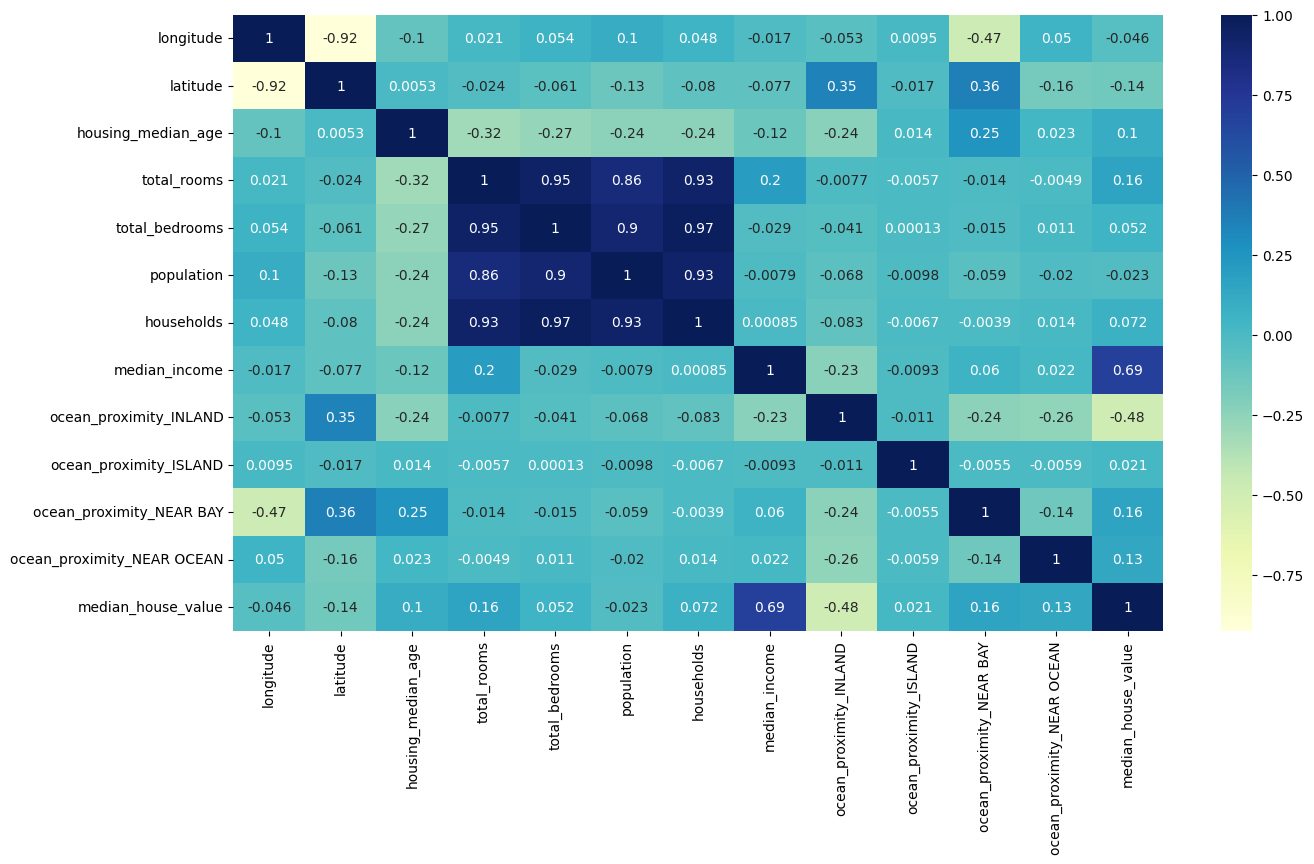

In [145]:
plt.figure(figsize=(15,8))
sns.heatmap(traindata.corr(), annot=True, cmap='YlGnBu')

<Axes: xlabel='latitude', ylabel='longitude'>

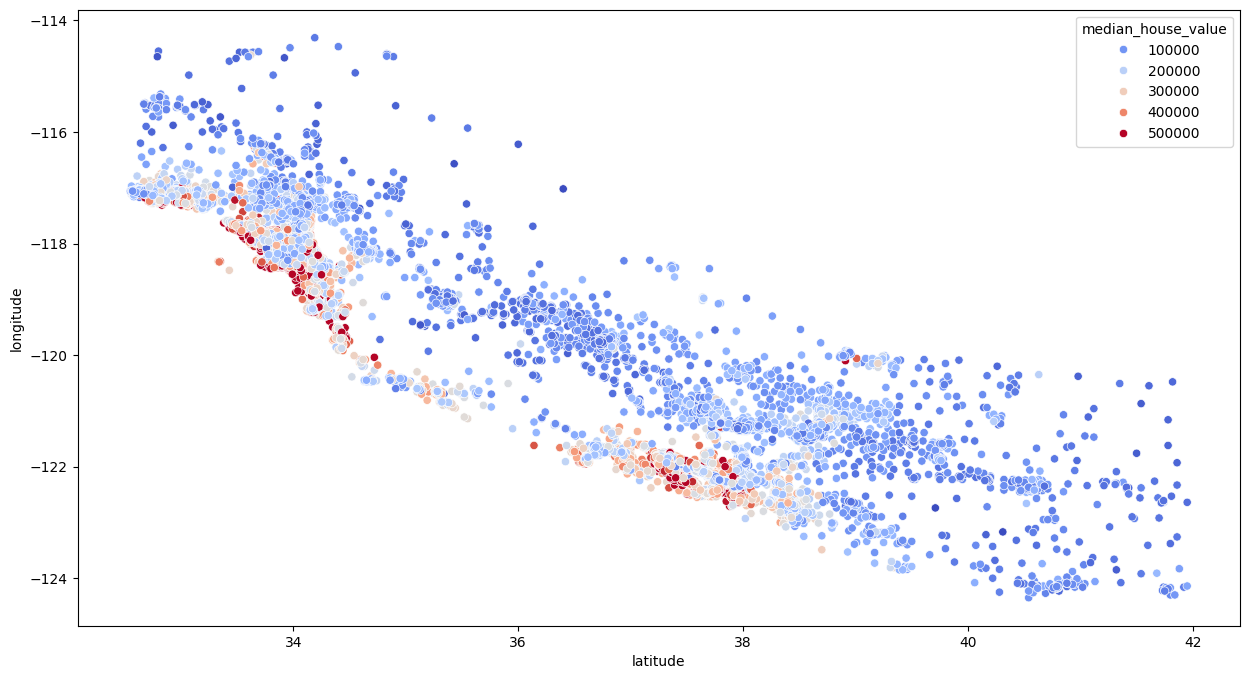

In [146]:
plt.figure(figsize=(15,8))
sns.scatterplot(x ='latitude', y='longitude', data=traindata, hue ='median_house_value', palette='coolwarm')

In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = LinearRegression()


pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lr)
])

In [148]:
pipe

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [149]:
pipe.fit(x_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [150]:
y_pred = pipe.predict(x_test)

In [151]:
lr.score(x_test, y_test)

c:\Users\Lucas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


-2270.3054945061635

In [152]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_pred, y_test))

49902.69525717369


In [155]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid= {
    'n_estimators': [3, 10, 30],
    'max_features': [2,4,6,8]
}

gridsearch = GridSearchCV(forest, param_grid, cv=5, 
                          scoring='neg_mean_absolute_error',
                          return_train_score=True)

gridsearch.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': [2, 4, 6, 8],
                         'n_estimators': [3, 10, 30]},
             return_train_score=True, scoring='neg_mean_absolute_error')

In [156]:
best_forest = gridsearch.best_estimator_

In [157]:
best_forest

RandomForestRegressor(max_features=8, n_estimators=30)

In [158]:
best_forest.score(x_test,y_test)

0.8141214533408054